In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from pathlib import Path
from mphsweepkit.plot_data import DataPlot, PlotSettings, PlotTextOverrides
from mphsweepkit.tex import *

In [2]:
# 1) Load result data exported by CascadedSweepModel.save_result_data(...)
result_dir = Path("global_data")  # adjust if needed
dp = DataPlot.from_result_folder(result_dir)

# 2) Inspect loaded data
print("Input shape:", dp.input_df.shape)
print("Output shape:", dp.output_df.shape)
print("Combined shape:", dp.combined_df.shape)

print("\nInput columns:", dp.input_columns())
print("Output columns:", dp.output_columns())

# 3) Access metadata
y_col = dp.output_columns()[0]
print(f"\nSelected output column: {y_col}")
print("Label:", dp.get_label(y_col))
print("Unit:", dp.get_unit(y_col))
print("Axis label:", dp.format_axis_label(y_col))

# 4) Access combined dataframe
dp.combined_df.head()

Input shape: (77, 7)
Output shape: (77, 2)
Combined shape: (77, 9)

Input columns: ['height', 'length', 'width', 'matsw.comp1.sw1', 'voltage', 'core_temperature', 'freq']
Output columns: ['Z', 'C']

Selected output column: Z
Label: Z
Unit: Ohm
Axis label: Z [Ohm]


,height,length,width,matsw.comp1.sw1,voltage,core_temperature,freq,Z,C
name,,,,,,,,,
unit,mm,mm,mm,NaN,V,NaN,Hz,Ohm,F
group,Geometry Sweep,Geometry Sweep,Geometry Sweep,Material Sweep,Excitation Sweep,Excitation Sweep,Frequency Sweep,post-processing,post-processing
0,10.0,20.0,2.0,1.0,10.0,60.0,100000.0,(173.8872944216915-329.87868426421386j),(3.7755684598794324e-09-1.990196444055384e-09j)
1,10.0,20.0,2.0,1.0,10.0,60.0,200000.0,(86.57926752728213-202.07467144885996j),(3.327238575473488e-09-1.4255615346919686e-09j)
2,10.0,20.0,2.0,1.0,10.0,60.0,300000.0,(57.90119038916195-146.61615087306285j),(3.1302174560627727e-09-1.2361756587095605e-09j)


Exemplary Visualization of average loss density in dependence of the geometry with the **DataPlot** class

x:\Till_data\repositories\MPhSweepKit\.venv\Lib\site-packages\pandas\core\base.py:689: ComplexWarning: Casting complex values to real discards the imaginary part
  result = np.asarray(values, dtype=dtype)


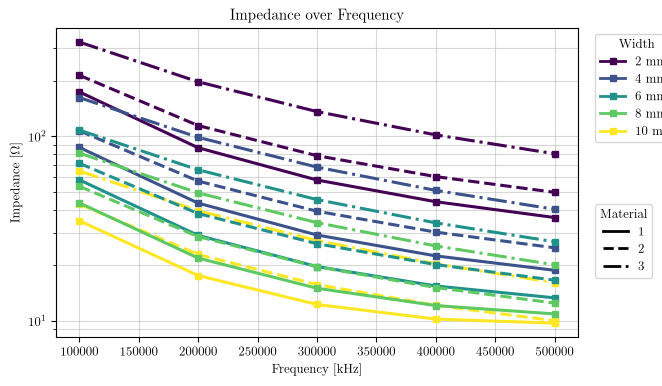

In [ ]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 10 / 2.54))  

custom_settings = PlotSettings(
    x_scale="linear",
    y_scale="log",
    show_grid=True,
    grid_which="both",
    grid_alpha=0.5,
    marker="s",
    marker_size=5,
    line_width=2.2,
    color_map_name="viridis",
    line_styles=("-", "--", "-.", ":"),
    show_color_legend=True,
    show_style_legend=True,
    use_tight_layout=True
)

# TODO: allow passing functions (maybe via lambda) for the computed results. e.g. to deal wth complex numbers -> phase and amplitude...

dp.y_over_x_with_color_and_style(
    ax,
    y_col="Z",
    x_col="freq",
    color_col="width",
    style_col="matsw.comp1.sw1",
    settings=custom_settings,
    text_overrides=PlotTextOverrides(
        x_label="Frequency",
        x_unit="kHz",
        y_label="Impedance",
        y_unit="$\\mathrm{\\Omega}$",
        color_label="Width",
        color_unit="mm",
        style_label="Material",
        style_unit=" ",
    ),
)

plt.show()